# Esercizio: introduzione di variabili esogene nella pipeline di Forecasting


Se abbiamo a disposizione ulteriori informazioni sul fenomeno sotto forma di $K$ **variabili esogene** (o regressori esterni) $x_1(t), x_2(t), \dots, x_K(t)$, possiamo estendere il nostro filtro introducendo una componente di regressione lineare. In questo scenario, l'uscita $y(t)$ non è spiegata unicamente dalla propria memoria stocastica passata, ma risente istantaneamente dell'effetto di segnali deterministici esterni (ad esempio dati climatici).

In un modello **regARIMA** (Regression with ARIMA errors), la serie storica viene scomposta formalmente in una **media condizionata deterministica** (la regressione lineare) e in un **residuo stocastico** $n(t)$ che cattura l'autocorrelazione temporale:

$$
y(t) = \underbrace{\sum_{k=1}^{K}\beta_k x_k(t)}_{\text{regressione esogena }\mu(t)} + \underbrace{n(t)}_{\text{errore ARMA}}
$$

In questo framework, il filtro autoregressivo non viene applicato direttamente a $y(t)$, ma viene applicato esclusivamente per "pulire" i residui $n(t) = y(t) - \sum_{k=1}^{K}\beta_k x_k(t)$. 

Se la serie dei residui richiede una differenziazione di ordine $d$ per diventare stazionaria, l'operatore di derivazione temporale viene applicato in modo lineare sia al target che alle variabili esogene, ottenendo $y^{(d)}(t)$ e $x_k^{(d)}(t)$. L'equazione alle differenze del filtro predittivo complessivo **regARIMA(p,d,q)** si compone quindi in questo modo:

$$
\hat{y}^{(d)}(t) = \underbrace{\sum_{k=1}^{K}\beta_k x_k^{(d)}(t)}_{\text{impatto esogeno presente}} + \underbrace{\sum_{i=1}^{p}a(i)\left[y^{(d)}(t-i) - \sum_{k=1}^{K}\beta_k x_k^{(d)}(t-i)\right]}_{\text{parte autoregressiva (AR) sui residui}} + \underbrace{\sum_{j=0}^{q}b(j)e(t-j)}_{\text{parte a media mobile (MA)}}
$$

dove $\beta_1, \dots, \beta_K$ sono i coefficienti di regressione da stimare (insieme ad $a(i)$ e $b(j)$) e l'operatore $y^{(d)}(t-i) - \sum_{k=1}^{K}\beta_k x_k^{(d)}(t-i)$ non è altro che il residuo storico (la differenza tra il dato reale e la regressione) valutato al tempo passato $t-i$. 

*Nota:* La parte Autoregressiva (AR) "ricorda" l'errore commesso nei passi precedenti e lo usa per correggere la previsione presente $\hat{y}^{(d)}(t)$, ma lo fa solo *dopo* aver rimosso l'impatto del trend deterministico e della stagionalità spiegati dalle variabili esogene.

---
## TASK 1 — Data Merging & Preprocessing

Costruiamo il dataset multivariato unendo i **casi settimanali di Dengue** a Fortaleza (Brasile) con le **tre variabili climatiche** disponibili:

| Variabile | File sorgente | Colonna usata |
|-----------|--------------|---------------|
| Temperatura minima | `tmin_weekly_indi_n1981_2010.csv` | `mean` |
| Temperatura massima | `tmax_weekly_indi_n1981_2010.csv` | `mean` |
| Umidità relativa | `rh_weekly_indi_n1981_2010.csv` | `mean` |


**Chiave di join:** `(iso_year, iso_week)` estratta da `calendar_start_date` nel dataset Spatial e dalla coppia `year/week` nei file climatici (codice IBGE Fortaleza = `2304400`).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")

from ts_utils import (
    # data
    load_climate_variable,
    # EDA
    plot_dengue_series,
    plot_climate_histograms,
    plot_correlation_heatmap,
    # CV
    plot_cv_splits,
    nested_walk_forward_bias_variance_ridge,
    nested_walk_forward_bias_variance_mlp,
    plot_walk_forward_complexity,
    plot_model_comparison,
    # regARIMA
    select_best_hyperparam,
    refit_on_train,
    plot_residual_acf_pacf,
    fit_arima_on_residuals,
    regarima_forecast,
    plot_regarima_forecast,
    # metrics
    compute_metrics,
    print_metrics_table,
)

DATA_DIR        = Path("../Data")
FORTALEZA_CODE  = 2304400
YEAR_MIN, YEAR_MAX = 2015, 2024
CLIMATE_VARS    = ["tmin", "tmax", "rh"]
LAG_RANGE       = range(1, 5)



### Trasformazione logaritmica del target

Per stabilizzare la varianza (tipicamente eteroschedastica nelle serie di conteggi epidemiologici) applichiamo:

$$y'_t = \log(y_t + 1)$$

L'addendo $+1$ evita $\log(0)$ nelle settimane senza casi registrati.

### Lag delle variabili climatiche

Il ciclo biologico di *Aedes aegypti* introduce un **ritardo biologico** tra l'anomalia climatica e la comparsa clinica del caso: la zanzara impiega circa 1–4 settimane per completare lo sviluppo larvale e trasmettere il virus. Per catturare questo effetto generiamo le versioni ritardate $x_k(t-\ell)$ per $\ell = 1, 2, 3, 4$ di ciascuna delle 3 variabili climatiche, ottenendo:

$$\mathbf{X}_t = \bigl[x_{\text{tmin}}(t{-}1),\dots,x_{\text{tmin}}(t{-}4),\; x_{\text{tmax}}(t{-}1),\dots,x_{\text{rh}}(t{-}4)\bigr] \in \mathbb{R}^{12}$$

Le prime 4 righe (che avrebbero lag mancanti) vengono scartate.

In [3]:
# ── Carica il dataset pulito prodotto in TASK 1 ──────────────────────────────
df = pd.read_csv(DATA_DIR / "Fortaleza_Dengue_Climate_2015_2025.csv",
                 parse_dates=["calendar_start_date"])

# ── Trasformazione log del target ────────────────────────────────────────────
df["y_log"] = np.log1p(df["dengue_total"])

# ── Lag delle variabili climatiche (t-1 … t-4) ───────────────────────────────
CLIMATE_VARS = ["tmin", "tmax", "rh"]
LAG_RANGE    = range(1, 5)

for var in CLIMATE_VARS:
    for lag in LAG_RANGE:
        df[f"{var}_lag{lag}"] = df[var].shift(lag)

# ── Rimuove le prime 4 righe con NaN introdotti dai lag ──────────────────────
MAX_LAG = max(LAG_RANGE)
df = df.iloc[MAX_LAG:].reset_index(drop=True)

# ── Riepilogo ────────────────────────────────────────────────────────────────
FEATURE_COLS = [f"{v}_lag{l}" for v in CLIMATE_VARS for l in LAG_RANGE]

print(f"Righe dopo rimozione lag iniziali: {len(df)}  (tolte {MAX_LAG})")
print(f"Feature climatiche con lag: {len(FEATURE_COLS)}")
print(f"  {FEATURE_COLS}")
print(f"\nStatistiche target trasformato:")
print(df[["dengue_total", "y_log"]].describe().round(3))

df[["calendar_start_date", "dengue_total", "y_log"] + FEATURE_COLS[:4]].head()

Righe dopo rimozione lag iniziali: 517  (tolte 4)
Feature climatiche con lag: 12
  ['tmin_lag1', 'tmin_lag2', 'tmin_lag3', 'tmin_lag4', 'tmax_lag1', 'tmax_lag2', 'tmax_lag3', 'tmax_lag4', 'rh_lag1', 'rh_lag2', 'rh_lag3', 'rh_lag4']

Statistiche target trasformato:
       dengue_total    y_log
count       517.000  517.000
mean        262.103    4.721
std         414.698    1.307
min           3.000    1.386
25%          41.000    3.738
50%         106.000    4.673
75%         257.000    5.553
max        2774.000    7.928


,calendar_start_date,dengue_total,y_log,tmin_lag1,tmin_lag2,tmin_lag3,tmin_lag4
0,2015-02-01,156.0,5.056246,25.342857,25.128571,25.308571,24.638572
1,2015-02-08,142.0,4.962845,24.780000,25.342857,25.128571,25.308571
2,2015-02-15,160.0,5.081404,25.531429,24.780000,25.342857,25.128571
3,2015-02-22,196.0,5.283204,24.511429,25.531429,24.780000,25.342857
4,2015-03-01,307.0,5.730100,23.687143,24.511429,25.531429,24.780000


### Exploratory Data Analysis

Tre sezioni:

1. **Serie temporale** — visualizzazione di `dengue_total` e `y_log` per identificare stagionalità, picchi anomali e trend.
2. **Distribuzioni** — istogrammi delle variabili climatiche (valori contemporanei, non laggati) per verificare normalità e asimmetria.
3. **Matrice di correlazione** — Pearson tra i 12 lag climatici e `y_log` per (a) identificare il lag con effetto più forte per ciascuna variabile e (b) rilevare collinearità tra regressori adiacenti.

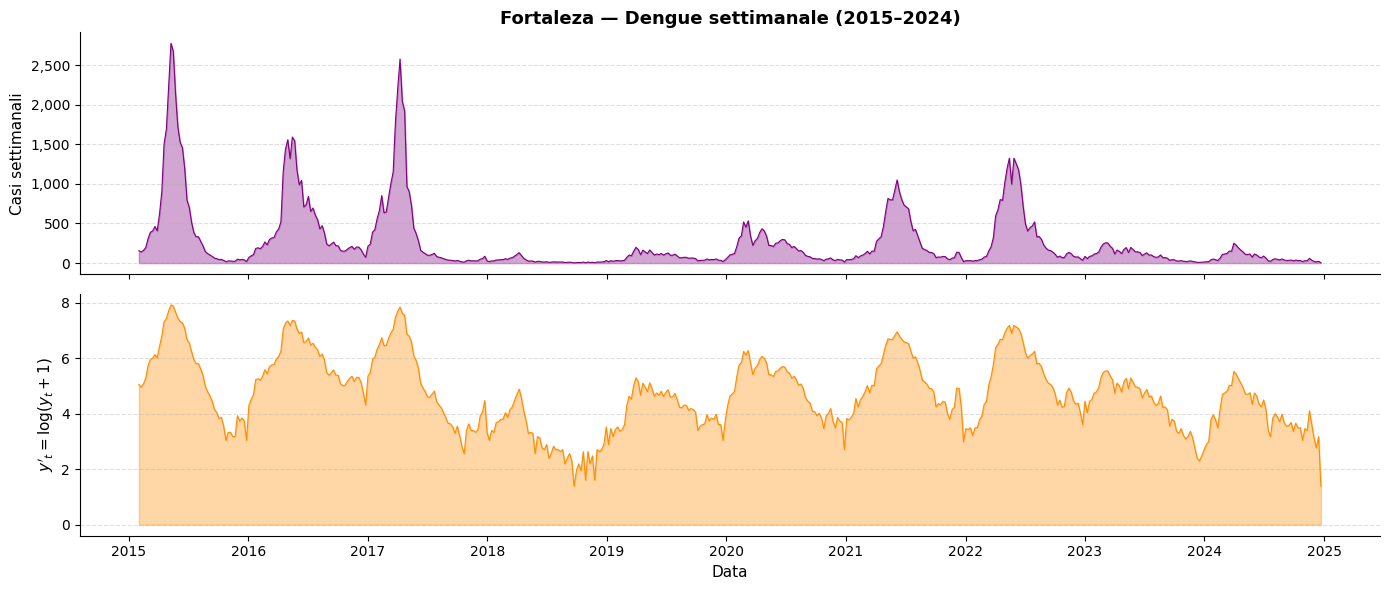

In [4]:
plot_dengue_series(df)

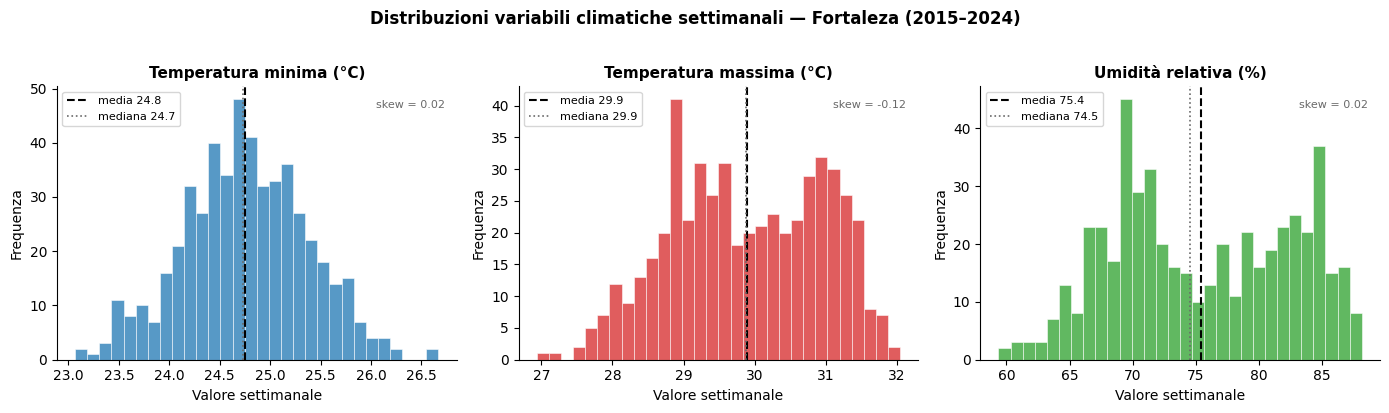

In [5]:
plot_climate_histograms(df)

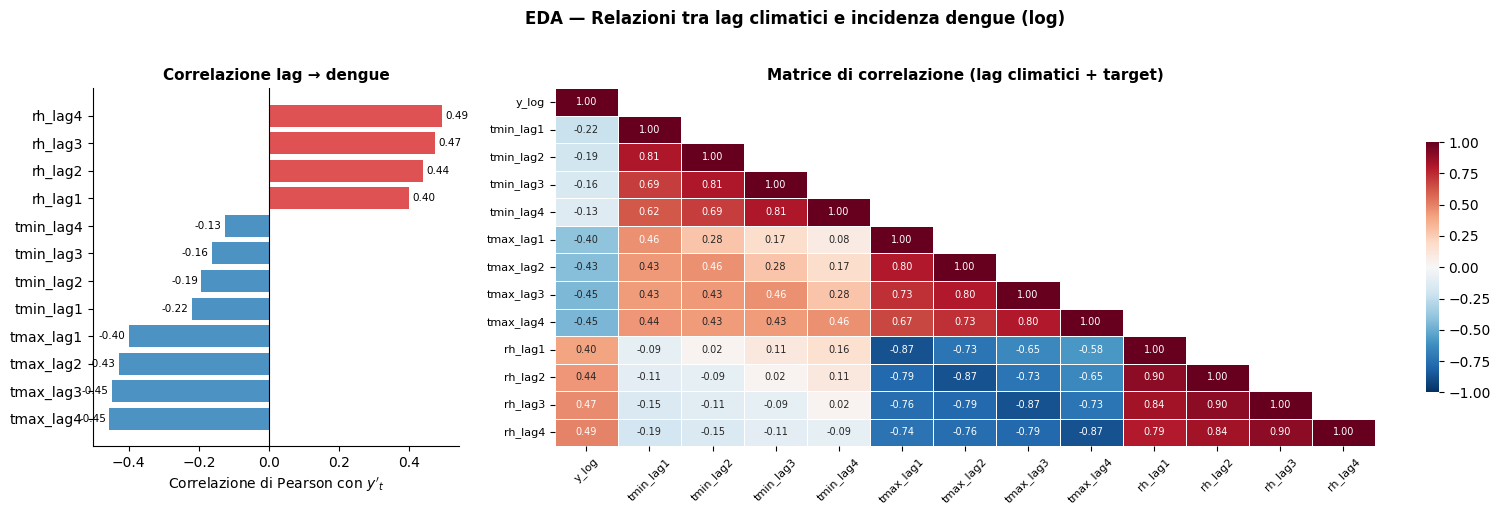


Lag con correlazione assoluta massima verso y_log:
  tmin  →  tmin_lag1  (r = -0.221)
  tmax  →  tmax_lag4  (r = -0.455)
  rh    →  rh_lag4  (r = +0.494)


In [6]:
FEATURE_COLS = [f"{v}_lag{l}" for v in CLIMATE_VARS for l in LAG_RANGE]
corr_matrix  = plot_correlation_heatmap(df, FEATURE_COLS, CLIMATE_VARS, LAG_RANGE)

**Distribuzioni climatiche** — Le tre variabili presentano skewness $\approx 0$ (tmin: 0.02, tmax: −0.12, rh: 0.02): le distribuzioni sono sostanzialmente simmetriche e gaussiane. Non è necessaria alcuna trasformazione delle esogene.

**Correlazioni con $y'_t = \log(\text{dengue}+1)$:**

| Variabile | Lag ottimale | $r$ | Interpretazione |
|-----------|-------------|-----|-----------------|
| `tmax` | lag-4 | −0.455 | Temperature molto elevate riducono la sopravvivenza della zanzara (effetto letale oltre ≈35 °C); il picco di correlazione a 4 settimane riflette il ciclo biologico completo. |
| `rh` | lag-4 | +0.494 | L'umidità favorisce la schiusa delle uova e la proliferazione larvale; il lag dominante a 4 settimane è coerente con il periodo di incubazione estrinseca del virus. |
| `tmin` | lag-1 | −0.221 | Effetto più debole e a ritardo breve: temperature notturne basse possono rallentare il metabolismo vettoriale nella settimana immediatamente successiva. |

**Collinearità** — La heatmap rivela alta correlazione tra lag consecutivi della stessa variabile (es. `rh_lag3` ↔ `rh_lag4` ≈ 0.97). La **Ridge regression** nel TASK 5 è la scelta naturale per gestire questa collinearità senza eliminare manualmente i regressori.


### Nested Walk-Forward Cross-Validation

Il K-Fold standard campiona i fold **in modo casuale**: un dato al tempo $t$ può finire nel training set mentre un dato a $t-1$ è nel validation set. Questo viola il vincolo di causalità e introduce **data leakage**, producendo stime di errore ottimisticamente distorte.

Per le serie storiche è necessario rispettare l'**ordine cronologico**. La strategia corretta è la **Nested Expanding Window CV**:

```
Outer fold 1:  ████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  ← train | test →
Outer fold 2:  ███████████████████░░░░░░░░░░░░░░░░░░░░░░
Outer fold 3:  ██████████████████████████░░░░░░░░░░░░░░░
...
Per ogni fold esterno, ciclo interno (stesso schema) → selezione iperparametri
```

### Garanzie anti-leakage implementate

1. **Scaling dentro ogni fold** — `StandardScaler` è incapsulato in una `sklearn.Pipeline`: viene fittato esclusivamente sul training set di ogni fold e applicato poi al validation set, senza alcun accesso ai dati futuri.
2. **Selezione iperparametri isolata** — il ciclo interno opera solo sui dati del ciclo esterno corrente (non sull'intero dataset).

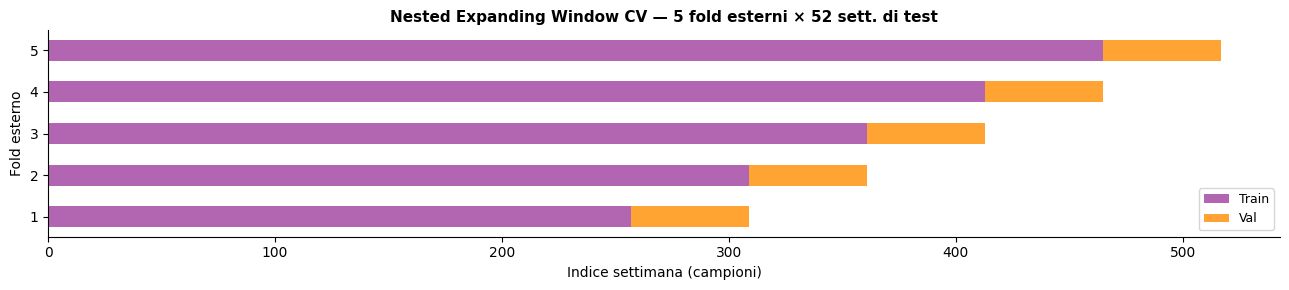

Dataset: 517 campioni totali
  Fold 1: train= 257 sett.  (2015-02-01 → 2019-12-29)  |  val=52 sett.  (2020-01-05 → 2020-12-27)
  Fold 2: train= 309 sett.  (2015-02-01 → 2020-12-27)  |  val=52 sett.  (2021-01-03 → 2021-12-26)
  Fold 3: train= 361 sett.  (2015-02-01 → 2021-12-26)  |  val=52 sett.  (2022-01-02 → 2022-12-25)
  Fold 4: train= 413 sett.  (2015-02-01 → 2022-12-25)  |  val=52 sett.  (2023-01-01 → 2023-12-24)
  Fold 5: train= 465 sett.  (2015-02-01 → 2023-12-24)  |  val=52 sett.  (2023-12-31 → 2024-12-22)


In [7]:
FEATURE_COLS = [f"{v}_lag{l}" for v in CLIMATE_VARS for l in LAG_RANGE]
X_all = df[FEATURE_COLS].values
y_all = df["y_log"].values

N_OUTER  = 5
N_INNER  = 3
HORIZON  = 52

plot_cv_splits(df, X_all, n_outer=N_OUTER, horizon=HORIZON)

### regARIMA con Ridge e MLP

L'architettura regARIMA si articola in tre fasi sequenziali:

1. **Ottimizzazione della regressione** — Ridge o MLP, selezionati con la Nested Walk-Forward CV del TASK 4.  
2. **Diagnostica dei residui** — ACF/PACF per identificare la struttura ARMA residua.  
3. **Filtro ARIMA sui residui** — cattura l'autocorrelazione della dinamica epidemica non spiegata dalle variabili climatiche.

**Split train/test fisso:** ultimi 2 anni (`N_TEST = 104`) come test set tenuto separato dalla nested CV.

### 5.1 — Train / Test split

In [8]:
N_TEST = 104   # ultimi 2 anni (2023 + 2024) come test set

X_train, X_test = X_all[:-N_TEST], X_all[-N_TEST:]
y_train, y_test = y_all[:-N_TEST], y_all[-N_TEST:]

print(f"Train: {len(X_train)} sett.  "
      f"({df['calendar_start_date'].iloc[0].date()} → "
      f"{df['calendar_start_date'].iloc[-N_TEST-1].date()})")
print(f"Test:  {len(X_test)} sett.  "
      f"({df['calendar_start_date'].iloc[-N_TEST].date()} → "
      f"{df['calendar_start_date'].iloc[-1].date()})")

Train: 413 sett.  (2015-02-01 → 2022-12-25)
Test:  104 sett.  (2023-01-01 → 2024-12-22)


### 5.2 — Ridge: Nested Walk-Forward CV + curva bias-varianza

NESTED WALK-FORWARD CV — Ridge Regression (Expanding Window)
  Outer: 4 fold × 52 sett.  |  Inner: 3 fold
  Alpha grid (7): [0.001, 0.01, 0.1, 1, 10, 100, 1000]
  [Fold 1]  N_train= 205  best_α=1000.0000  Inner-RMSE=1.6643  Outer-RMSE=0.9161  R²=-1.2121
  [Fold 2]  N_train= 257  best_α=1000.0000  Inner-RMSE=1.6292  Outer-RMSE=0.6362  R²=0.4739
  [Fold 3]  N_train= 309  best_α=100.0000  Inner-RMSE=1.3618  Outer-RMSE=1.1485  R²=-0.2724
  [Fold 4]  N_train= 361  best_α=1000.0000  Inner-RMSE=1.4150  Outer-RMSE=1.0997  R²=0.1721

  RMSE esterno: 0.9501 ± 0.2009
  R²   esterno: -0.2096 ± 0.6368


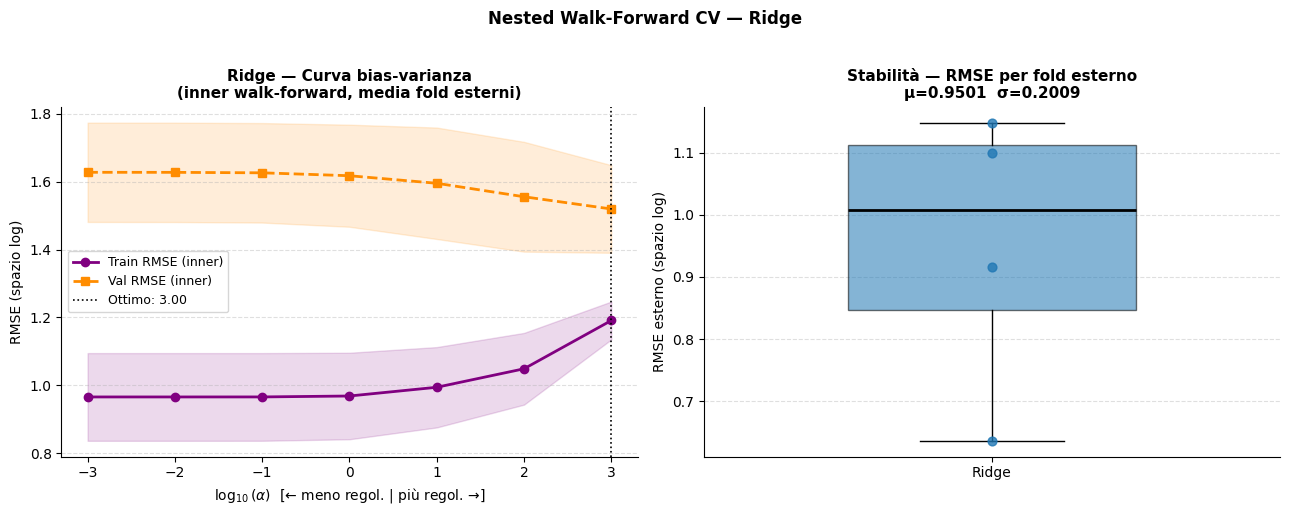

In [9]:
ALPHA_GRID = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_cv = nested_walk_forward_bias_variance_ridge(
    X_train, y_train,
    alpha_list=ALPHA_GRID,
    n_outer=4, n_inner=3,
    min_train_size=52, horizon=52,
)
plot_walk_forward_complexity(
    ridge_cv,
    model_name="Ridge",
    x_col="log_alpha",
    x_label=r"$\log_{10}(\alpha)$  [← meno regol. | più regol. →]",
)

NESTED WALK-FORWARD CV — MLP Regressor (Expanding Window)
  Outer: 4 fold × 52 sett.  |  Inner: 3 fold
  Griglia: 12 config (depth=[1, 2, 3] × units=[16, 32, 64, 128])
  [Fold 1]  N_train= 205  best_hls=(16, 16)            Inner-RMSE=1.9019  Outer-RMSE=1.4095  R²=-4.2369
  [Fold 2]  N_train= 257  best_hls=(128,)              Inner-RMSE=1.7919  Outer-RMSE=0.7136  R²=0.3382
  [Fold 3]  N_train= 309  best_hls=(128,)              Inner-RMSE=1.4414  Outer-RMSE=1.5329  R²=-1.2665
  [Fold 4]  N_train= 361  best_hls=(32, 32)            Inner-RMSE=1.5580  Outer-RMSE=1.4015  R²=-0.3449

  RMSE esterno: 1.2644 ± 0.3222
  R²   esterno: -1.3775 ± 1.7463


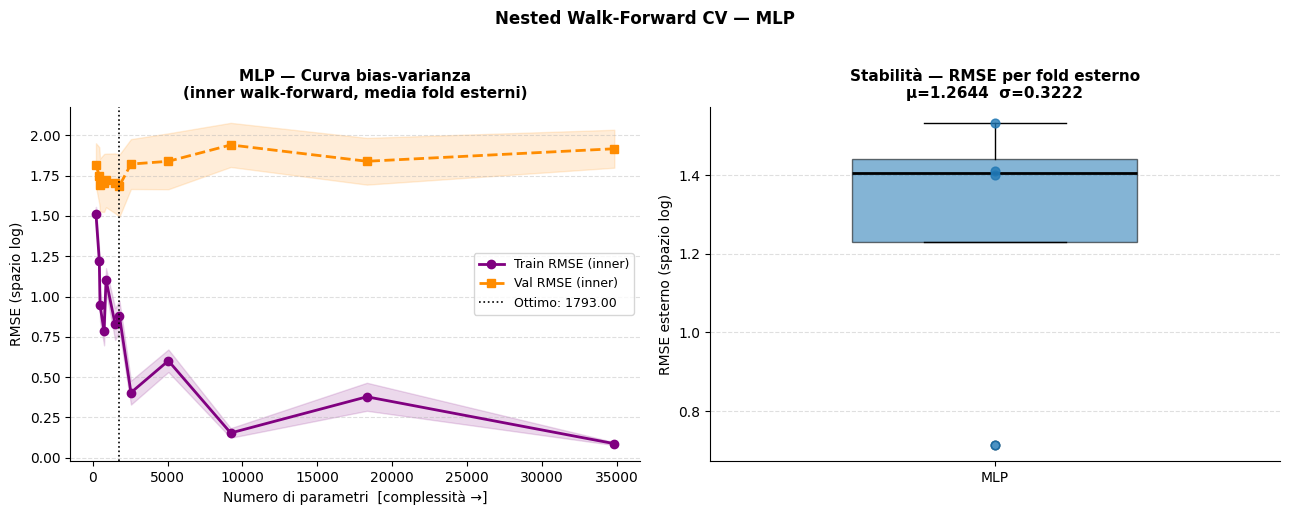

In [10]:
DEPTH_GRID = [1, 2, 3]
UNITS_GRID = [16, 32, 64, 128]

mlp_cv = nested_walk_forward_bias_variance_mlp(
    X_train, y_train,
    depth_list=DEPTH_GRID,
    n_units_list=UNITS_GRID,
    n_features=len(FEATURE_COLS),
    n_outer=4, n_inner=3,
    min_train_size=52, horizon=52,
)
plot_walk_forward_complexity(
    mlp_cv,
    model_name="MLP",
    x_col="n_params",
    x_label="Numero di parametri  [complessità →]",
)

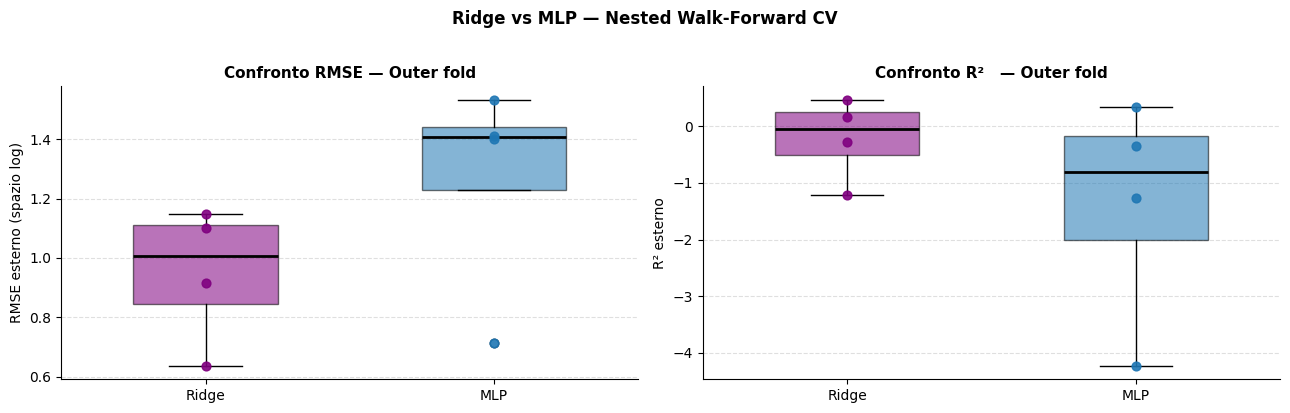


Riepilogo:
  Ridge  RMSE=0.9501±0.2009  R²=-0.2096±0.6368
  MLP    RMSE=1.2644±0.3222  R²=-1.3775±1.7463

Modello vincitore : RIDGE
Best alpha               : 1000


In [11]:
plot_model_comparison(ridge_cv, mlp_cv)

# ── Selezione automatica del vincitore per RMSE medio esterno ────────────────
winner = "ridge" if ridge_cv["mean_rmse"] <= mlp_cv["mean_rmse"] else "mlp"
winner_cv = ridge_cv if winner == "ridge" else mlp_cv
param_key = "ridge__alpha" if winner == "ridge" else "mlp__hidden_layer_sizes"

best_value = select_best_hyperparam(winner_cv, param_key)
print(f"\nModello vincitore : {winner.upper()}")
print(f"Best {param_key.split('__')[1]:20s}: {best_value}")

### Refit sul training completo + diagnostica dei residui

Il modello vincitore viene refittato sull'intero training set con l'iperparametro ottimale (maggioranza dei fold nested CV). I residui $\hat{e}_t = y'_t - \hat{m}(\mathbf{x}_t)$ vengono analizzati via ACF/PACF per identificare la struttura ARMA rimanente.

Residui — media: -0.0000  std: 1.2151  (ideale: media≈0, struttura autocorrelata)


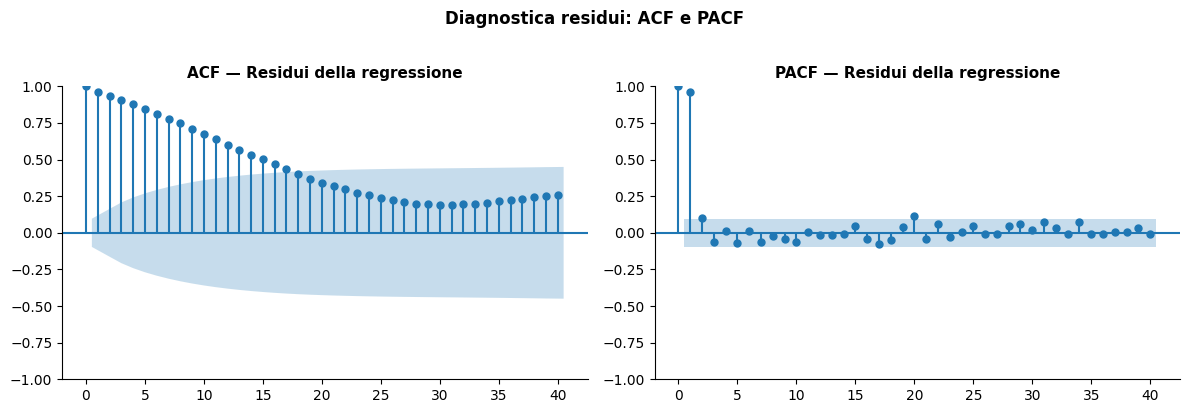

In [12]:
best_reg_model  = refit_on_train(X_train, y_train, winner, best_value)
residuals_train = y_train - best_reg_model.predict(X_train)

print(f"Residui — media: {residuals_train.mean():.4f}  "
      f"std: {residuals_train.std():.4f}  "
      f"(ideale: media≈0, struttura autocorrelata)")

plot_residual_acf_pacf(residuals_train)

Il filtro ARIMA viene selezionato sulla griglia `arima_orders` tramite inner `TimeSeriesSplit` applicato ai soli residui di training — rispettando l'ordine temporale anche in questa fase.

In [13]:
ARIMA_ORDERS = [
    (1, 0, 0), (2, 0, 0), (3, 0, 0),
    (0, 0, 1), (1, 0, 1), (2, 0, 1),
    (1, 0, 2), (1, 1, 1), (2, 1, 1),
]

arima_res = fit_arima_on_residuals(
    residuals_train,
    arima_orders=ARIMA_ORDERS,
    n_inner=3,
    min_train_size=52,
)

print(f"\nTop-3 ordini ARIMA per RMSE inner:")
for entry in arima_res["order_rmses"][:3]:
    print(f"  ARIMA{entry['order']}  RMSE={entry['inner_rmse']:.4f}")

  INNER CV — selezione ordine ARIMA sui residui
  Grid: 9 ordini  |  Inner fold: 3
  ARIMA(1, 0, 0)  Inner-RMSE=1.1581
  ARIMA(2, 0, 0)  Inner-RMSE=1.2334
  ARIMA(3, 0, 0)  Inner-RMSE=1.1853
  ARIMA(0, 0, 1)  Inner-RMSE=1.1293
  ARIMA(1, 0, 1)  Inner-RMSE=1.2301
  ARIMA(2, 0, 1)  Inner-RMSE=1.1339
  ARIMA(1, 0, 2)  Inner-RMSE=1.1905
  ARIMA(1, 1, 1)  Inner-RMSE=1.9140
  ARIMA(2, 1, 1)  Inner-RMSE=1.9300

  → Best order: ARIMA(0, 0, 1)  (RMSE=1.1293)
  Fit finale su tutti i residui di training…

Top-3 ordini ARIMA per RMSE inner:
  ARIMA(0, 0, 1)  RMSE=1.1293
  ARIMA(2, 0, 1)  RMSE=1.1339
  ARIMA(1, 0, 0)  RMSE=1.1581


### 5.7 — Previsione finale e confronto con le baseline

La previsione regARIMA combina la componente di regressione e quella ARIMA sui residui. Vengono confrontati tre modelli:

| Modello | Descrizione |
|---------|-------------|
| **Persistence** | $\hat{y}_t = y_{t-1}$ — baseline ingenua, usata come lower bound |
| **Regressione only** | $\hat{y}_t = \hat{m}(\mathbf{x}_t)$ — solo la componente climatica |
| **regARIMA** | $\hat{y}_t = \hat{m}(\mathbf{x}_t) + \hat{e}_t^{\text{ARIMA}}$ — architettura completa |

Test set: 104 settimane
  Regressione    — media: 4.776  std: 0.438
  ARIMA forecast — media: -0.004   std: 0.045
  Combinato      — media: 4.772   std: 0.442


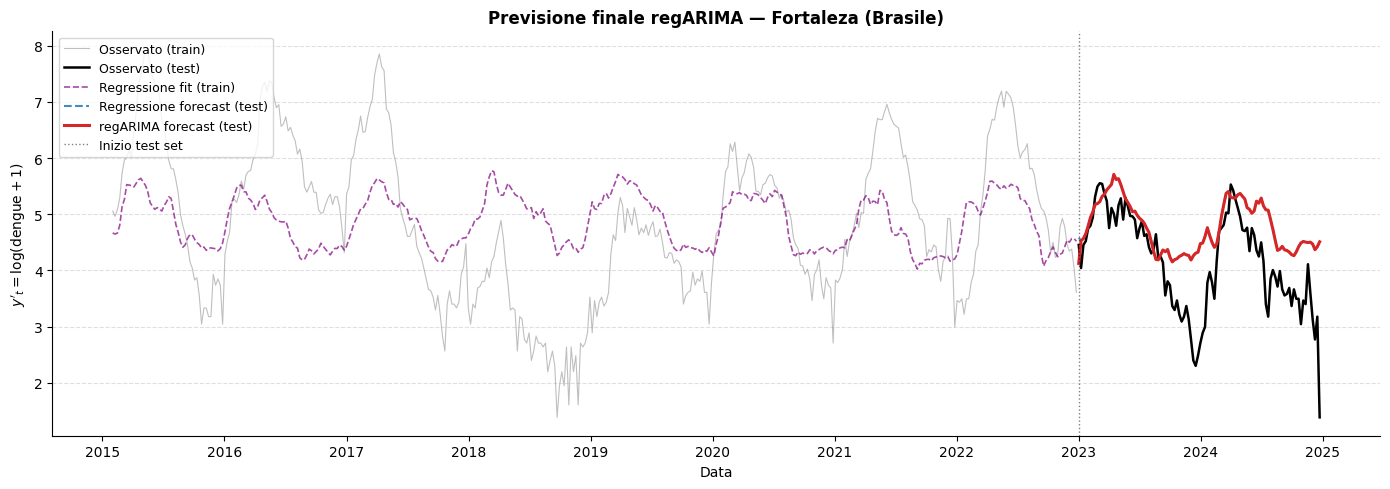


Modello                    RMSE      MAE       R²
------------------------------------------------------
Persistence (lag-1)      0.3538   0.2613   0.8296
Regressione (RIDGE)      0.8621   0.6594  -0.0120
regARIMA (RIDGE+ARIMA(0, 0, 1))   0.8626   0.6614  -0.0132


In [14]:
fc = regarima_forecast(
    best_reg_model, X_test,
    arima_res["fitted_model"],
)

reg_preds_train = best_reg_model.predict(X_train)
plot_regarima_forecast(df, y_all, N_TEST, reg_preds_train, fc)

# ── Persistence baseline: y_hat_t = y_{t-1} ─────────────────────────────────
persistence = y_all[-(N_TEST + 1):-1]

metrics_table = {
    f"Persistence (lag-1)":          compute_metrics(y_test, persistence),
    f"Regressione ({winner.upper()})": compute_metrics(y_test, fc["reg_preds"]),
    f"regARIMA ({winner.upper()}+ARIMA{arima_res['best_order']})":
                                      compute_metrics(y_test, fc["combined"]),
}
print()
print_metrics_table(metrics_table)

---
## Nota finale — Perché il MLP usato qui non è un vero modello neurale per serie temporali

### Quello che abbiamo fatto

Il MLP (e la Ridge) ricevono in input un **vettore piatto** $\mathbf{x}_t \in \mathbb{R}^{12}$, costruito manualmente concatenando i lag climatici:

$$
\mathbf{x}_t = [\,x_{\text{tmin}}(t{-}1),\, x_{\text{tmin}}(t{-}2),\, x_{\text{tmin}}(t{-}3),\, x_{\text{tmin}}(t{-}4),\;\dots\;,\, x_{\text{rh}}(t{-}4)\,]
$$

Il modello è un **regressore tabellare standard**: non vede sequenze, non ha memoria interna, e non sa che le 12 feature provengono da una serie ordinata nel tempo. La struttura temporale è codificata *interamente nel preprocessing* (la costruzione dei lag), non nell'architettura.

---

### Cosa sarebbe un vero approccio neurale per serie temporali

Un modello come **LSTM** (Long Short-Term Memory) o **GRU** riceve direttamente la **finestra temporale come tensore** $(T \times F)$, dove:
- $T$ = lunghezza della finestra (es. 8 settimane)
- $F$ = numero di variabili per passo temporale (es. `tmin`, `tmax`, `rh`, e opzionalmente `y_log` stessa)

L'input per il campione al tempo $t$ sarebbe:

$$
\mathbf{X}_t =
\begin{bmatrix}
x_{\text{tmin}}(t{-}T) & x_{\text{tmax}}(t{-}T) & x_{\text{rh}}(t{-}T) & y'(t{-}T) \\
\vdots & \vdots & \vdots & \vdots \\
x_{\text{tmin}}(t{-}1) & x_{\text{tmax}}(t{-}1) & x_{\text{rh}}(t{-}1) & y'(t{-}1)
\end{bmatrix}
\in \mathbb{R}^{T \times 4}
$$

La rete processa la sequenza **passo dopo passo**, aggiornando uno **stato nascosto** $\mathbf{h}_t$ che funge da memoria:

$$
\mathbf{h}_t = f_{\theta}(\mathbf{h}_{t-1},\, \mathbf{x}_t), \qquad \hat{y}'_t = g_{\phi}(\mathbf{h}_T)
$$

Le porte dell'LSTM (input, forget, output) imparano autonomamente **quali lag e quali variabili sono rilevanti** — non serve specificare a priori `lag1..4`.

---

### Confronto diretto

| Aspetto | MLP con lag manuali (questo notebook) | LSTM / GRU |
|---------|---------------------------------------|------------|
| **Input** | vettore piatto $\mathbb{R}^{12}$ | tensore sequenza $\mathbb{R}^{T \times F}$ |
| **Struttura temporale** | codificata nel preprocessing | appresa dall'architettura |
| **Lag** | fissati a priori (1..4 settimane) | appresi dai dati (qualsiasi lunghezza) |
| **Memoria** | nessuna — ogni sample è indipendente | stato nascosto $\mathbf{h}_t$ persistente |
| **Lags di $y$** | assenti (delegati all'ARIMA) | inclusi naturalmente nella finestra |
| **Forecast ricorsivo** | non necessario (esogene note) | possibile con teacher forcing / autoregressive decoding |
| **Complessità** | bassa, interpretabile | alta, richiede più dati e tuning |

---

### Perché il nostro approccio è comunque valido

1. **Dati limitati**: 517 settimane non bastano per addestrare un LSTM in modo affidabile. Le reti ricorrenti richiedono dataset molto più lunghi per non andare in overfitting.
2. **Interpretabilità**: la Ridge con lag espliciti permette di leggere i coefficienti $\beta_k$ e verificare il segno e la forza di ogni lag — un LSTM è una scatola nera.
3. **Framework regARIMA**: la separazione tra componente climatica (regressione) e componente stocastica (ARIMA sui residui) è un modello statistico con solide basi teoriche, usato in epidemiologia anche su serie corte.
4. **Baseline robusta**: Ridge + ARIMA spesso **batte** reti più complesse quando i dati sono pochi, la stagionalità è forte e le esogene sono informative — esattamente il caso della dengue.

Un LSTM sarebbe la scelta naturale con dati a risoluzione giornaliera su decenni, o in un contesto multi-città dove si può sfruttare il trasferimento spaziale dell'informazione.